# 事前準備：共通コードの実行
* このノートブックに接続したら，まずは以下の2つの共通コード（コードAとコードB）を実行する
* これらの共通コードを実行しないと，それ以降のコードが実行できないので注意する
* また，コードA，コードB，及びコードC は，ノートブックに接続するたび毎回実行すること（ノートブックに接続中は，何度も実行する必要はない）
* 共通コードの詳細についての説明は割愛する（簡単な説明は[第2回のサンプルノートブック](https://colab.research.google.com/github/yoshida-nu/lecture_public/blob/main/datascience/doc/datascience_notebook02.ipynb)を参照）

In [ ]:
# コードA：日本語化ライブラリ導入
! pip install japanize-matplotlib | tail -n 1

In [1]:
# コードB：共通事前処理

# B1:余分なワーニングを非表示にする
import warnings
warnings.filterwarnings('ignore')

# 必要ライブラリのimport
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib # matplotlib日本語化対応
import seaborn as sns

# B2:データフレーム表示用関数
from IPython.display import display

# B3:表示オプション調整
np.set_printoptions(suppress = True, precision = 3) #numpyの浮動小数点の表示精度
pd.options.display.float_format = '{:.3f}'.format #pandasでの浮動小数点の表示精度
pd.set_option('display.max_columns', None) #データフレームですべての列データを表示

# B4:グラフのデフォルトフォント指定
plt.rcParams['font.size'] = 14

# 乱数の種
random_seed = 0

In [2]:
# コードC：データのダウンロード
!curl -L -o iris.csv https://raw.githubusercontent.com/yoshida-nu/lecture_public/main/datascience/resources/06/iris.csv
!curl -L -o cinema.csv https://raw.githubusercontent.com/yoshida-nu/lecture_public/main/datascience/resources/06/cinema.csv

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100   4373 100   4373   0      0  11005      0                              0
100   4373 100   4373   0      0  11001      0                              0
100   4373 100   4373   0      0  10995      0                              0
  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100   3270 100   3270   0      0   8333      0                              0
100   3270 100   3270   0      0   8330      0                              0
100   3270 100   3270   0      0   8326      0                              0


# 目的と到達目標

## 目的
* 線形回帰モデルの学習のしくみを理解する

## 到達目標
* 予測値と実際の値のずれを表す「損失関数」を用いて，線形回帰モデルの学習のしくみを説明できる
* 線形回帰によるデータ分析を実践できる


# 線形回帰

## 回帰とは
* 説明変数から説明変数から数値（量的データの目的変数）を予測する
* 回帰を目的とする機械学習モデル（回帰モデル）は様々
* 例えば，線形回帰，多項式回帰，Redge回帰，Lasso回帰，回帰木など
* 回帰の例
  * 例1：身長から体重を予測
  * 例2：営業所に配置するセールスマン数から売上を予測
  * 例3：年齢，喫煙の有無，血圧から，ある病気の発症リスクを予測
  * 例4：地域，築年数，面積から中古マンションの価格を予測
  * 例5：顔画像から年齢を予測

  <img src="./fig/example_regression.jpg" width='400'>


## 線形回帰モデル
* ここでは，上述した「例2：営業所に配置するセールスマン数から売り上げを予測」について考える
* 各営業所について，次のデータ（訓練データ）が得られているとする

|営業所$i$|売上$t_i$（億円）|セールスマン$x_i$（人）|
|:-:|:-:|:-:|
| $1$ | $t_1=3$ | $x_1=1$ |
| $2$ | $t_2=3$ | $x_2=2$ |
| $3$ | $t_3=4$ | $x_3=3$ |
| $4$ | $t_4=5$ | $x_4=4$ |
| $5$ | $t_5=5$ | $x_5=5$ |

* 散布図を描いてみる（下図）

  <img src='./fig/example_regression_scatter.jpg" width="500">

* セールスマン数が6人のときの売上はどれくらい？ ⇒ 線形回帰モデルで予測できる

### 線形回帰モデルによる予測
* 線形回帰では，セールスマン数$𝑥$と売上$𝑦$の間に，次のような関係式が成立していると仮定
$$
𝑦=𝑓(𝑥)=𝑎𝑥+𝑏
$$
* このモデルを線形回帰モデルと呼ぶ
  * $𝑥$を説明変数，$𝑦$を目的変数と呼ぶ
  * 「説明変数は目的変数に回帰する」ということになる
* このモデルを学習することでセールスマン数が6人のときの売上が予測できる
* 線形回帰モデルの学習⇒訓練データから，パラメータ$𝑎$と$𝑏$を決める

### 線形単回帰モデル
* 上の例のように，説明変数が一つの線形回帰モデルを，特に線形単回帰モデルと呼ぶ
* 線形単回帰モデルにおいては，$𝑎$を回帰係数，$𝑏$を定数項と呼ぶ
* $a$と$b$の両方を回帰係数と呼ぶこともある

  <img src="./fig/example_regression_line.jpg" width="400">

### 線形単回帰モデルの学習（回帰係数と定数項の決め方）
* すべての訓練データに対して，$t=𝑓(𝑥)=𝑎𝑥+𝑏$を満たす$a$と$b$の組み合わせは存在しない（下図）

  <img src="./fig/example_regression_learning1.jpg" width="400">

* 完全に一致はしないが，訓練データとよく当てはまっているモデル（直線）になるように回帰係数と定数項を決める
* そのために，「当てはまり具合」を定量的に表現した損失関数を定める
* 損失関数は，モデル（回帰係数と定数項），及び訓練データによって定まる関数で，その値が小さいほど当てはまりのよいモデルとなる
* 具体的には，説明変数$𝑥$におけるモデルの出力（直線上の値）である $𝑓(𝑥)$ と目的変数（正解データ）$𝑡$ の差（誤差）の2乗の平均値である平均二乗誤差関数を損失関数とする
* 下図は誤差のイメージを示したものである

  <img src="./fig/example_regression_loss_function.jpg" width="400">

* 平均二乗誤差関数の定義： 
$$
\frac{1}{n} \sum_{i=1}^{n} \left( t_i - f(x_i) \right)^2
= \frac{1}{n} \sum_{i=1}^{n} \left( t_i - (a x_i + b) \right)^2
$$
* モデルの学習では，この平均二乗誤算関数が最小になる回帰係数$a$と定数項$b$を求める
* 平均二乗誤差関数の最小化によって，以下の回帰係数と定数項が得られる
$$
a = \frac{\displaystyle \sum_{i=1}^{n}(x_i-\bar{x})(t_i-\bar{t})}{\displaystyle \sum_{i=1}^{n}(x_i-\bar{x})^2},
\qquad b=\bar{t}-a\bar{x},
$$
$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i, 
\qquad \bar{t} = \frac{1}{n}\sum_{i=1}^{n}t_i
$$

### 線形重回帰モデル
* 説明変数が2つ以上（$𝑚$個）$\bm{x}=(𝑥_1, 𝑥_2, \ldots, x_m)$の線形回帰モデルを，線形重回帰モデル（あるいは単に線形回帰モデル）と呼ぶ
$$
𝑓(\bm{x}) = 𝑎_1 𝑥_1 + 𝑎_2 𝑥_2 + \cdots + 𝑎_m 𝑥_m + 𝑏
$$
* 線形重回帰モデルにおける回帰係数は偏回帰係数と呼ぶ（本講義では単に回帰係数と呼ぶ）

### 説明変数が2個の線形重回帰モデルのイメージ
* 説明変数が2個 $\bm{x}=(𝑥_1, 𝑥_2)$ の線形重回帰モデル: $𝑓(\bm{x}) = 𝑎_1 𝑥_1 + 𝑎_2 𝑥_2 + 𝑏$
* 線形単回帰モデルのような「直線」ではなく「面」のモデルとなる

  <img src="./fig/example_regression_plane.jpg" width="400">

# 線形単回帰モデルによるデータ分析例

## 用いるデータと分析の目的
* 例として，csvファイル「iris.csv」を用いる
  * 出典: 須藤秋良, 株式会社フレアリンク: スッキリわかるPythonによる機械学習入門, インプレス, 2020
* アヤメデータを用いて「花弁長さ」から「花弁幅」を予測することを考える
* そのために，説明変数$x$を「花弁長さ」，目的変数$y$を「花弁幅」とした線形単回帰モデル $𝑦=𝑓(𝑥)=𝑎𝑥+𝑏$ の学習を行う

## 実習：データの読み込みと欠損値への対処
* アヤメデータの各説明変数には欠損値が存在する
* これまでと同様にして，csvファイルを読み込み後，欠損値を各説明変数の算術平均で置き換える

**［実習内容］**
* 「以下のコードの処理内容」に従って，コードを完成させる
* 空行に適切なコードを記述する

**［以下のコードの処理内容］**
* 2行目: pandasの`read_csv`関数を使って，ファイルをDataFrameとして読み込んで，変数`df`に代入
* 3行目: `fillna`メソッドを使って，欠損値を各説明変数（がく片長さ, がく片幅, 花弁長さ, 花弁幅）の算術平均にそれぞれ置き換えて変数`df`に代入
* 4行目: `isnull`メソッドと`any`メソッドで，`df`の中で欠損値がある列を確認し，その結果を`display`関数で表示

**［実行結果］**

  <img src="./fig/exercise_regression_iris_missing.jpg" width="150">

In [ ]:
# 欠損値の補完


display(pd.DataFrame(df.isnull().any(axis=0), columns=['欠損値']))

## 実習：花弁長さと花弁幅の散布図の作成
*  pypolotモジュールの`scatter`関数で散布図を作成できる
*  詳細は[第2回のサンプルノートブック](https://colab.research.google.com/github/yoshida-nu/lecture_public/blob/main/datascience/doc/datascience_notebook02.ipynb)を参照

**［実習内容］**
* 「以下のコードの処理内容」に従って，コードを完成させる
* 空行に適切なコードを記述する

**［以下のコードの処理内容］**
*  2～3行目: ファイルの読み込みと欠損値への対処
*  4行目: `scatter`関数を使って花弁長さと花弁幅の散布図を作成
  * `df['花弁長さ']`でx軸を指定
  * `df['花弁幅']`でy軸を指定
*  5～6行目: `xlabel`関数と`ylabel`関数各軸のラベルをそれぞれ「花弁長さ」「花弁幅」に設定
*  7行目: `show`関数で，それまでに設定した図（散布図）を実行画面に表示

**［実行結果］**

  <img src="./fig/exercise_regression_iris_scatter.jpg" width="350">

In [ ]:
# 花弁長さと花弁幅の散布図の作成





plt.show()

## モデルの学習

## `linear_model`モジュール
* scikit-learnの`linear_model`モジュールを読み込むことで線形回帰モデルが利用できる
  * 線形単回帰モデルと線形重回帰モデルは，どちらも`linear_model`モジュールを用いる
* インポートの書式： `from sklearn.linear_model import LinearRegression`
* `linear_model`モジュールには「線形」で表現できる様々なモデルを扱うためのクラスが複数用意されている
* モデルの学習をするためには，対応するクラスのオブジェクトをまずは生成する必要がある
* 線形回帰モデルの場合は，`linear_model`モジュールにおける`LinearRegression`クラスのオブジェクトを生成する
* オブジェクト生成の書式: `変数 = LinearRegression()`
  * 引数は指定しない
  * 線形回帰モデルでは分類木モデルのような乱数を使った学習は行わない（乱数を使わない）
  * 一般に生成したオブジェクトを変数に代入して利用する

## 学習の実行
* オブジェクトを生成したら，線形回帰モデルの学習を実行する
* 学習は，これまでと同様にホールドアウト法を用いる ⇒ データを訓練データとテストデータに分割する
* 分類木と同様に，線形回帰モデルの学習は，`fit`メソッドを利用して実行する
* `fit`メソッドの引数には，説明変数と目的変数（正解データ）を指定する
* モデルの学習の書式: `変数.fit(X=[説明変数], y=[目的変数])`
  * 変数名はオブジェクトを代入した変数の名前
  * 「`X=`」で説明変数，「`y=`」で目的変数を指定する
* 学習済みモデルの情報は，`fit`メソッドを適用後のオブジェクトの属性から参照できる
* 同様にモデルの評価のために必要な情報も属性から参照できる
  
**［以下のコードの処理内容］**
* 2行目: pandasの`read_csv`関数を使って，ファイルをDataFrameとして読み込んで，変数`df`に代入
* 3行目: `fillna`メソッドを使って，`df.fillna(df[['がく片長さ','がく片幅', '花弁長さ', '花弁幅']].mean())`とし，欠損値を各説明変数の算術平均にそれぞれ置き換えて変数`df`に代入
* 4行目: 説明変数の列名を要素とするリスト`['花弁長さ']`を変数`x_cols`に代入
* 5行目: 目的変数の列名（リスト）`['花弁幅']`を変数`t_col`に代入
* 6行目: DataFrame `df` から,`df[x_cols]`で，説明変数の列だけ取り出し変数`x`に代入
* 7行目: DataFrame `df` から,`df[t_col]`で目的変数の列だけ取り出し変数`t`に代入
* 8行目: `model_selection`モジュールの`train_test_split`関数の読み込み
* 9行目: `train_test_split`関数を使って説明変数データ`x`と目的変数データ（正解データ）`t`を訓練データとテストデータにそれぞれ分割
  * `test_size=0.3`として，訓練データを7割，テストデータを3割に分割
  * `random_state=random_seed`として，乱数を固定する ⇒ 結果が同じになる
  * `x_train`: 訓練データの説明変数データ
  * `x_test`: テストデータの説明変数データ
  * `t_train`: 訓練データの目的変数データ
  * `t_test`: テストデータの目的変数データ
* 10行目:  `sklearn` (scikit-learn) の`linear_model`モジュール内にある`LinearRegression`クラスをインポートする 
* 11行目: `LinearRegression()`で，線形回帰モデルの学習を行うためのオブジェクトを`LinearRegression`クラスから生成し，変数`linear_regression_model`に代入
* 12行目: `fit`メソッドで線形回帰モデルの学習を実行
* 13行目: `print`関数で「学習完了」と表示

In [ ]:
# 学習の実行
df = pd.read_csv('iris.csv')
df = df.fillna(df[['がく片長さ', 'がく片幅', '花弁長さ', '花弁幅']].mean())
x_cols = ['花弁長さ']
t_col = ['花弁幅']
x = df[x_cols]
t = df[t_col]
from sklearn.model_selection import train_test_split
x_train, x_test, t_train, t_test = train_test_split(x, t, test_size=0.3, random_state=random_seed)
from sklearn.linear_model import LinearRegression
linear_regression_model = LinearRegression()
linear_regression_model.fit(X=x_train, y=t_train)
print('学習完了')

学習完了


## 実習：学習済みモデルを使った予測
* 目的変数の値が未知の説明変数データから目的変数の値を推測することを予測と呼ぶ
  * 今回の例は回帰に対する予測
* 予測は`predict`メソッドを用いる
  * 書式: `変数.predict(X=説明変数)`
  * 戻り値は予測結果
  * 予測結果のデータ型はNumPyの配列（ndarray）

**［実習内容］**
* 「以下のコードの処理内容」に従って，コードを完成させる
* 空行に適切なコードを記述する

**［以下のコードの処理内容］**
* 2～3行目: データの読み込み，欠損値の対処（これまでと同様）
* 4～7行目: 説明変数と目的変数に分割（これまでと同様）
* 8～9行目: 訓練データとテストデータに分割（これまでと同様）
* 10～12行目: モデルの学習（これまでと同様）
* 13行目: 新しい3個の説明変数データのリスト`[[1.5], [3.8], [6.1]]`を変数`newdata`に代入
* 14行目: `predict`メソッドを用いて，新たな説明変数データ`newdata`に対する予測を行い，その結果（`predict`メソッドの戻り値）を変数`y_pred`に代入
  *  `predict`メソッドの引数で指定する`X`のクラス（データ型）は，厳密には ndarray または DataFrame にする必要がある
  *  ここでは，問題なく実行できるので，リストのまま使用している
* 15行目: `print`関数で，「予測結果：」と表示
* 16行目: 予測結果`y_pred`を`print`関数で表示

**［実行結果］**
```
予測結果：
[[1.544]
 [4.025]
 [6.505]]
```

In [ ]:
# 学習済みモデルによる予測











newdata = [[1.5], [3.8], [6.1]]

print('予測結果：')
print(y_pred)

予測結果：
[[1.544]
 [4.025]
 [6.505]]


## モデルの評価
* 分類を目的としたモデルの評価で使われている指標の「精度（Accuracy）」は，モデルの予測結果（分類結果）が当たっているかどうかを見ている
* つまり，目的変数が質的データであるから意味がある
* 回帰のように目的変数が量的データの場合には意味がない
* 回帰の場合は，モデルの予測結果と実際の値（正解データ）がどれくらい近いかを見る
* 回帰モデルの評価指標としては，平均絶対誤差や決定係数などが使われる
  * 平均絶対誤差は予測結果と実際の値の差の絶対値の算術平均なので，データの性質を十分理解していないと評価できない
  * 一方，決定係数は客観的な評価指標となる
* 今回は決定係数でモデルを評価する

## 決定係数の確認
* $n$個の説明変数と目的変数（正解データ）の組$(x_1, t_1), (x_2, t_2), \ldots , (x_n, t_n)$に対する決定係数 $r_{xy}^{2}$ は以下の式で定義される
$$
r_{xy}^{2} = 1 - \frac{\sum_{i=1}^{n} \left( t_i - y_i \right)^2}{\sum_{j=1}^{n} \left( t_i - \bar{t} \right)^2}
$$
* $y_i$は学習済みモデル$f$による$x_i$に対する予測値: $y_i = f (x_i)$
* $\bar{t}$ は目的変数データの算術平均: ${\displaystyle\bar{t} = \frac{1}{n}\sum_{i=1}^{n}t_i}$
* 決定係数は 0から1の間に値をとる客観的な評価指標（寄与率とも呼ばれる）
* 決定係数が1に近いほどモデルの予測結果と実際の値との当てはまりが良い
* 例えば，説明変数の値に関係なく目的変数の平均$\bar{t}$で予測，すなわち $y_i = f (x_i) = t_i$ の場合，第2項が1となり，決定係数は0となる
* 一般に0.8以上であれば良いモデルといえる（ただし，問題の領域による）
* 決定係数は，`LinearRegression`クラスのオブジェクトに対する `score`メソッドで計算できる
  * 書式: `score(X=[説明変数], y=[目的変数])`
  
**［以下のコードの処理内容］**
* 2～3行目: データの読み込み，欠損値の対処（これまでと同様）
* 4～7行目: 説明変数と目的変数に分割（これまでと同様）
* 8～9行目: 訓練データとテストデータに分割（これまでと同様）
* 10～12行目: モデルの学習（これまでと同様）
* 13行目: `linear_regression_model.score(X=x_train, y=t_train)`で，訓練データに対する決定係数を計算して変数`score_train`に代入
* 14行目: `linear_regression_model.score(X=x_test, y=t_test)`で，テストデータに対する決定係数を計算して変数`score_test`に代入
* 15行目: `print`関数とf-stringを使って，訓練データに対する決定係数（`score_train`）とテストデータに対する決定係数（`score_test`）を小数点以下3桁まで表示
  * f-string `f'決定係数: {score:.3f}'` の `:.3f`で表示桁を小数点以下3桁までに指定

In [ ]:
# モデルの評価
df = pd.read_csv('iris.csv')
df = df.fillna(df[['がく片長さ', 'がく片幅', '花弁長さ', '花弁幅']].mean())
x_cols = ['花弁長さ']
t_col = ['花弁幅']
x = df[x_cols]
t = df[t_col]
from sklearn.model_selection import train_test_split
x_train, x_test, t_train, t_test = train_test_split(x, t, test_size=0.3, random_state=random_seed)
from sklearn.linear_model import LinearRegression
linear_regression_model = LinearRegression()
linear_regression_model.fit(X=x_train, y=t_train)
score_train = linear_regression_model.score(X=x_train, y=t_train)
score_test = linear_regression_model.score(X=x_test, y=t_test)
print(f'訓練データの決定係数={score_train:.3f} / テストデータの決定係数={score_test:.3f}')

訓練データの決定係数=0.649 / テストデータの決定係数=0.434


## 回帰係数の確認
* 学習した線形回帰モデルの回帰係数と定数項を確認する
* 回帰係数と定数項はオブジェクトの属性から確認できる
  * 回帰係数: `変数.coef_`
  * 定数項: `変数.intercept_`

**［以下のコードの処理内容］**
* 2～3行目: データの読み込み，欠損値の対処（これまでと同様）
* 4～7行目: 説明変数と目的変数に分割（これまでと同様）
* 8～9行目: 訓練データとテストデータに分割（これまでと同様）
* 10～12行目: モデルの学習（これまでと同様）
* 13行目: `coef_`属性から回帰係数（定数項以外）を取り出し，変数`a`に代入
* 14行目: `intercept_`属性から定数項を取り出し，変数`b`に代入
* 15行目: `print`関数とf-stringを使って，回帰係数`a`を表示を小数点以下3桁で表示
* 16行目: `print`関数とf-stringを使って，定数項`b`を小数点以下3桁で表示

In [ ]:
# 回帰係数の確認
df = pd.read_csv('iris.csv')
df = df.fillna(df[['がく片長さ', 'がく片幅', '花弁長さ', '花弁幅']].mean())
x_cols = ['花弁長さ']
t_col = ['花弁幅']
x = df[x_cols]
t = df[t_col]
from sklearn.model_selection import train_test_split
x_train, x_test, t_train, t_test = train_test_split(x, t, test_size=0.3, random_state=random_seed)
from sklearn.linear_model import LinearRegression
linear_regression_model = LinearRegression()
linear_regression_model.fit(X=x_train, y=t_train)
a = linear_regression_model.coef_
b = linear_regression_model.intercept_
print(f'回帰係数（定数項以外）: {a[0][0]:.3f}')
print(f'定数項: {b[0]:.3f}')

回帰係数（定数項以外）: 1.078
定数項: -0.073


## 学習済み線形単回帰モデル
* これまでの結果より，アヤメデータの線形単回帰モデルの形は以下のようになる（小数点以下3桁まで）
$$
𝑓(𝑥)=1.078𝑥−0.073
$$
* 上式から $𝑥=1.5$ のときの予測値を計算（コードで予測した結果と比較してみる）
$$
1.078×1.5−0.073=1.544
$$
* モデルから説明変数の値が1増加（減少）することで目的変数にどれだけ影響するかがわかる
* 説明変数（花弁長さ）の値が1増加すると目的変数（花弁幅）が約1.078増加する


## 線形単回帰モデルの可視化
* 線形単回帰モデル$f(x)$は，説明変数と目的変数（正解データ）の散布図上に，直線として描画できる
* 直線は `pyplot`モジュールの`plot`関数を用いる
* `plot`関数の引数
  * 1番目: x軸の値
  * 2番目: y軸の値
  * `color`: 線の色（`red`, `blue`など）
  * `label`: 直線の名前（凡例に表示）
* 凡例は，`legend`関数を呼び出すことで表示できる
  * 書式: `legend()`
* x座標の値は，NumPyモジュールの`linspace`関数を使って指定する
* `linspace`関数は，指定された区間を等分割した数列を生成する関数
  * 書式: `np.linspace([開始値], [終了値], [要素数])`
  * 例: `np.linspace(0, 1, 11)` ⇒ 数列 0.0 , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0 を生成
* `linspace`関数で生成した数列を`predict`メソッドの引数とすることで，数列の各要素に対する予測値を取得できる
* 取得した予測値を`plot`関数の2番目の引数（y軸の値）とする
  
**［以下のコードの処理内容］**
* 2～3行目: データの読み込み，欠損値の対処（これまでと同様）
* 4～7行目: 説明変数と目的変数に分割（これまでと同様）
* 8～9行目: 訓練データとテストデータに分割（これまでと同様）
* 10～12行目: モデルの学習（これまでと同様）
* 13行目: NumPyモジュールの`linspace`関数で，0～1の区間を等分割した100個の数列を生成し，変数`x_plot`に代入
* 14行目: `predict`メソッドで，`x_plot`の各値（100個）に対する予測値を計算
  * `predict`メソッドの引数は，DataFrameで指定する必要があるので，`DataFrame`関数を使って`x_plot`をDataFrameに変換する
  * 計算した100個の予測値を変数`y_plot`に代入
* 15行目: pylotモジュールの`scatter`関数で，花弁長さと花弁幅の散布図を作成
* 16行目: pylotモジュールの`plot`関数で，`x_plot`と`y_plot`の直線を描画
  * 引数`color=red`で直線の色を赤に設定
  * 引数`label='線形単回帰モデル'` でラベル「線形単回帰モデル」を設定
* 17行目: `legend`関数で凡例を表示
* 18行目: `show`関数で，それまでに設定した図（散布図と直線）を実行画面に表示


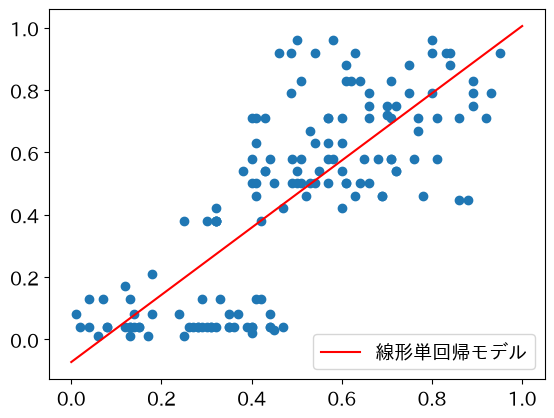

In [12]:
# モデルの可視化
df = pd.read_csv('iris.csv')
df = df.fillna(df[['がく片長さ', 'がく片幅', '花弁長さ', '花弁幅']].mean())
x_cols = ['花弁長さ']
t_col = ['花弁幅']
x = df[x_cols]
t = df[t_col]
from sklearn.model_selection import train_test_split
x_train, x_test, t_train, t_test = train_test_split(x, t, test_size=0.3, random_state=random_seed)
from sklearn.linear_model import LinearRegression
linear_regression_model = LinearRegression()
linear_regression_model.fit(X=x_train, y=t_train)
x_plot = np.linspace(0, 1, 100)
y_plot = linear_regression_model.predict(pd.DataFrame(x_plot))
plt.scatter(x, t)
plt.plot(x_plot, y_plot, color='red', label='線形単回帰モデル')
plt.legend()
plt.show()

# 線形重回帰モデルによるデータ分析例

## 用いるデータと分析の目的
* 例として，csvファイル「cinema.csv」を用いる
* このデータは，これまでに公開された映画の興行収入のデータ（映画データと呼ぶ）である
  * 出典: 須藤秋良, 株式会社フレアリンク: スッキリわかるPythonによる機械学習入門, インプレス, 2020
  * 著者が作成したオリジナルのデータ
  * データ数は100個

|**列名**| **内容** |
|:--|:--|
|cinema_id| 映画作品のID |
|SNS1| 公開後10日以内にSNS1で投稿された数 |
|SNS2| 公開後10日以内にSNS2で投稿された数 |
|actor| 主演俳優の昨年のメディア露出度（値が大きいほど露出している） |
|original| 原作の有無（ある「1」，ない「0」） |
|sales| 最終的な興行収入（単位: 万円） |

* 映画データを用いて，「SNS1」「SNS2」「actor」「original」から「興行収入」を予測することを考える
* そのために，4つの説明変数$x_1, x_2, x_3, x_4$を「SNS1」「SNS2」「actor」「original」，目的変数$y$を「興行収入」とした線形重回帰モデル（以降は，単に線形回帰モデルと呼ぶ）の学習を行う
$$
𝑦=𝑓(𝑥_1, 𝑥_2, 𝑥_3, 𝑥_4 )
=a_1 x_1 + a_2 x_2 + a_3 x_3 + a_4 x_4 + b
$$

  <img src="./fig/exercise_regression_cinema_model.jpg" width="550">

## データの読み込みと欠損値の確認
* これまでと同様にして，データの読み込みと欠損値の確認をする
* データ（csvファイル）の読み込みは，pandasの`read_csv`関数を使う
* 欠損値がある列の確認を pandasの`isnull`メソッドと`any`メソッドを使う
  * 欠損値がある列が「`True`」となる
  * 詳細は[第3回のサンプルノートブック](https://colab.research.google.com/github/yoshida-nu/lecture_public/blob/main/datascience/doc/datascience_notebook03.ipynb)を参照

**［以下のコードの処理内容］**
* 2行目: pandasの`read_csv`関数を使って，ファイルをDataFrameとして読み込んで，変数`df`に代入
* 3行目: `isnull`メソッド，`any`メソッド，及び`DataFrame`関数を使って，`df`の中で欠損値がある列を確認し，その結果を`display`関数で表示
* 実行結果から「SNS1」と「actor」に欠損値があることが確認できる

In [10]:
# データの読み込みと欠損値の確認
df = pd.read_csv('cinema.csv')
display(pd.DataFrame(df.isnull().any(axis=0), columns=['欠損値']))

,欠損値
cinema_id,False
SNS1,True
SNS2,False
actor,True
original,False
sales,False


## 実習：欠損値への対処
* `fillna`メソッドを使って，欠損値を対応する説明変数の算術平均に置き換える
  * 詳細は[第3回のサンプルノートブック](https://colab.research.google.com/github/yoshida-nu/lecture_public/blob/main/datascience/doc/datascience_notebook03.ipynb)を参照

**［実習内容］**
* 「以下のコードの処理内容」に従って，コードを完成させる
* 空行に適切なコードを記述する

**［以下のコードの処理内容］**
* 2行目: pandasの`read_csv`関数を使って，ファイルをDataFrameとして読み込んで，変数`df`に代入
* 3行目: `fillna`メソッドを使って，とし，欠損値を各説明変数の算術平均`df.mean()`にそれぞれ置き換えて変数`df`に代入
* 4行目: 一つ前のコードと同様にして，`df`の中で欠損値がある列を確認し，その結果を`display`関数で表示

**［実行結果］**

  <img src="./fig/exercise_regression_cinema_missing.jpg" width="150">

In [ ]:
# 映画データの欠損値への対処




,欠損値
cinema_id,False
SNS1,False
SNS2,False
actor,False
original,False
sales,False


## 外れ値の確認
* 他の値から大きく外れた値のことを**外れ値**と呼ぶ
* 前回扱った分類木モデルは外れ値に影響を受けにくいモデルなので省略したが，一般に，データの前処理では外れ値の確認も行う
* 外れ値は各説明変数と目的変数の散布図（散布図行列）を作成して視覚的に確認する
* 散布図行列の作成については，[第2回のサンプルノートブック](https://colab.research.google.com/github/yoshida-nu/lecture_public/blob/main/datascience/doc/datascience_notebook02.ipynb)を参照
  
**［以下のコードの処理内容］**
* 2～3行目: データの読み込みと欠損値への対処
* 4行目: seabornモジュールの`pairplot`関数を使って，`sns.pairplot(df)`とし，散布図行列を作成
* 5行目: `show`関数で，それまでに設定した図（散布図行列）を実行画面に表示

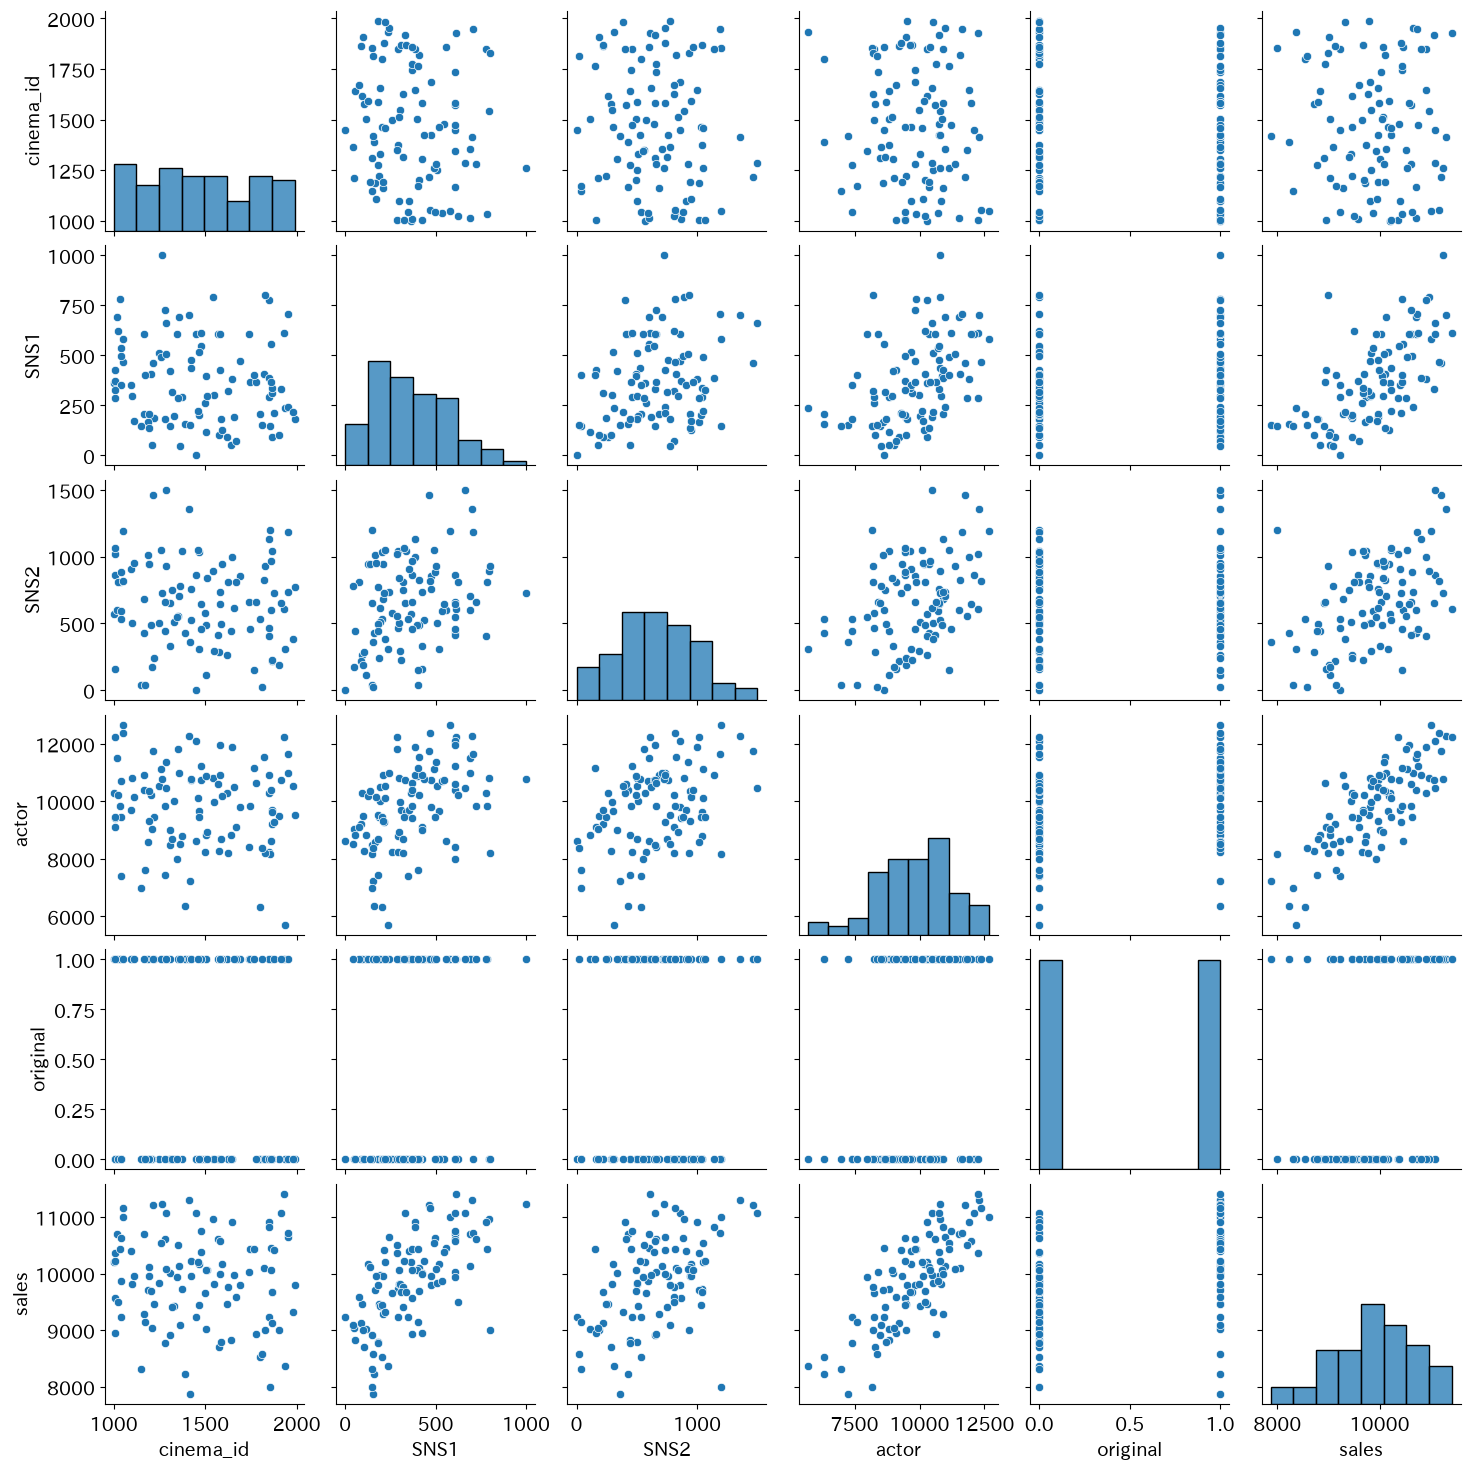

In [6]:
# 映画データの外れ値の確認
df = pd.read_csv('cinema.csv')
df = df.fillna(df.mean())
sns.pairplot(df)
plt.show()

* 散布図行列から，SNS2とsalesの散布図で外れ値が確認できる
* SNS1とsalesの散布図でも外れ値らしきものはあるが，今回は通常のデータとして扱う
* SNS2とsalesの散布図で外れ値が確認できたので，SNS2とsalesの散布図のみを作成して，サイズの大きい散布図で再度確認してみる
  
**［以下のコードの処理内容］**
* 2～3行目: データの読み込みと欠損値への対処
* 4行目: `scatter`関数を使ってSNS2とsalesの散布図を作成
  * `df['SNS2']`でx軸を指定
  * `df['sales']`でy軸を指定
* 5～6行目: `xlabel`関数と`ylabel`関数各軸のラベルをそれぞれ「SNS2」「sales」に設定
* 7行目: `show`関数で，それまでに設定した図（散布図）を実行画面に表示

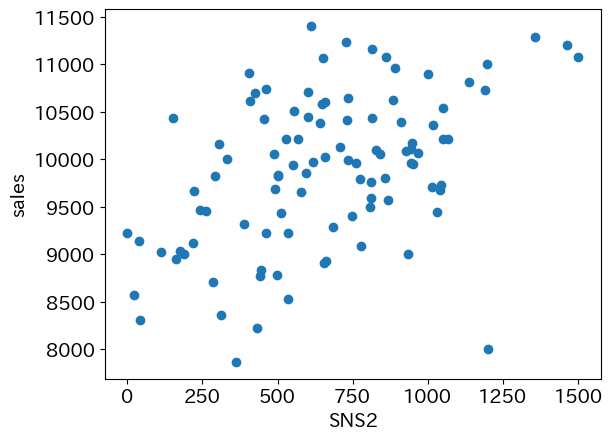

In [ ]:
# 映画データの散布図作成
df = pd.read_csv('cinema.csv')
df = df.fillna(df.mean())
plt.scatter(df['SNS2'], df['sales'])
plt.xlabel('SNS2')
plt.ylabel('sales')
plt.show()

## 外れ値の検索
* 散布図から外れ値の存在が確認できた
* しかし，具体的にどのデータなのか正確な値がわからない ⇒ 散布図から外れ値となるデータの大体の値はわかる
* 散布図より，外れ値のデータは SNS2が1000より大きくて，salesが8500未満であることがわかる
* これらを条件として，DataFrameから該当するデータを検索する
* DataFrameにおけるデータの検索は，共通資料「[ノートブック：SeriesとDataFrameの基本操作](https://colab.research.google.com/github/yoshida-nu/lecture_public/blob/main/datascience/doc/datascience_notebook_se_df.ipynb)」を参照
  
**［以下のコードの処理内容］**
* 2～3行目: データの読み込みと欠損値への対処
* 4行目: DataFrame `df` から，SNS2が1000より大きく（`df['SNS2'] > 1000`），かつsalesが8500未満（`df['sales'] < 8500`）のデータを抽出し，`display`関数で表示
  * 条件式は`(df['SNS2'] > 1000) & (df['sales'] < 8500)`となる

In [7]:
# 映画データの外れ値の検索
df = pd.read_csv('cinema.csv')
df = df.fillna(df.mean())
display(df[(df['SNS2'] > 1000) & (df['sales'] < 8500)])

,cinema_id,SNS1,SNS2,actor,original,sales
30,1855,149.000,1200,8173.097,0,8000


## 外れ値の削除
* 上記の実行結果より，外れ値がインデックス「30」のデータであることが特定できたので，DataFrameに対する`drop`メソッドを使って，該当データを削除する
* DataFrameにおけるデータの削除は，共通資料「[ノートブック：SeriesとDataFrameの基本操作](https://colab.research.google.com/github/yoshida-nu/lecture_public/blob/main/datascience/doc/datascience_notebook_se_df.ipynb)」を参照
  
**［以下のコードの処理内容］**
* 2～3行目: データの読み込みと欠損値への対処
* 4行目: `drop`メソッドを使って，インデックス「30」のデータを削除し，その結果を`df`に再代入
* 5行目: `display`関数を使って，`df`の内容を表示
  * データ数（行数）が1個減って，99個になっていることが確認できる

In [8]:
# 映画データの外れ値の削除
df = pd.read_csv('cinema.csv')
df = df.fillna(df.mean())
df = df.drop(30, axis=0)
display(df)

,cinema_id,SNS1,SNS2,actor,original,sales
0,1375,291.000,1044,8808.994,0,9731
1,1000,363.000,568,10290.709,1,10210
2,1390,158.000,431,6340.389,1,8227
3,1499,261.000,578,8250.485,0,9658
4,1164,209.000,683,10908.540,0,9286
...,...,...,...,...,...,...
95,1260,494.000,1050,11137.483,1,10537
96,1283,505.000,928,11376.039,1,10084
97,1861,368.000,966,10393.252,0,10069
98,1006,326.000,1068,9454.020,1,10218


## 実習：映画データの一連の分析
* 以下のコードで，線形回帰モデルの学習，予測，及び評価を行う

**［分析の流れ］**
* データの読み込み，欠損値への対処，外れ値の削除
* 説明変数と目的変数に分割
  * 説明変数： SNS1，SNS2，actor，original
  * 目的変数： 興行収入
* 説明変数と目的変数を訓練データとテストデータにそれぞれ分割
  * 訓練データを8割，テストデータを2割に分割
  * `random_seed`で乱数を固定
* 線形回帰モデルの学習（線形単回帰モデルの学習と同様）
* 学習済みモデルで，以下の2つの説明変数に対する興行収入（目的変数）を予測（線形単回帰モデルの予測と同様）
  * SNS1=150，SNS2=700，actor=300，original=0
  * SNS1=200，SNS2=500，actor=400，original=1
* 決定係数によるモデルの評価（線形単回帰モデルの評価と同様）
* 学習済みモデルの回帰係数と定数項の確認（線形単回帰モデルと同様）

**［実習内容］**
* 「以下のコードの処理内容」に従って，コードを完成させる
* 空行に適切なコードを記述する

**［以下のコードの処理内容］**
* 2～4行目: データの読み込み，欠損値への対処，及び外れ値の削除（これまでと同様の処理）
* 5行目: 説明変数の列名を要素とするリスト`['SNS1','SNS2', 'actor', 'original']`を変数`x_cols`に代入
* 6行目: 目的変数の列名（リスト）`['sales']`を変数`t_col`に代入
* 7行目: DataFrame `df` から,`df[x_cols]`で，説明変数の列だけ取り出し変数`x`に代入
* 8行目: DataFrame `df` から,`df[t_col]`で目的変数の列だけ取り出し変数`t`に代入
* 9行目: `model_selection`モジュールの`train_test_split`関数のインポート
* 10行目: `train_test_split`関数を使って説明変数`x`と目的変数`t`を訓練データ（80％）とテストデータ（20％）にそれぞれ分割
* 11行目:  `sklearn` (scikit-learn) の`linear_model`モジュール内にある`LinearRegression`クラスをインポート
* 12行目: `LinearRegression()`で，線形回帰モデルの学習を行うためのオブジェクトを`LinearRegression`クラスから生成し，変数`linear_regression_model`に代入
* 13行目: 訓練データ`x_train`と`t_train`を用いて，`fit`メソッドで線形回帰モデルの学習を実行
* 14行目: 新しい1個の説明変数データ（`['SNS1','SNS2', 'actor', 'original']`）のリスト`[[150, 700, 300, 0], [200, 500, 400, 1]]`を変数`newdata`に代入
* 15行目: `predict`メソッドを用いて，`newdata`に対する予測を行い，その結果を変数`y_pred`に代入
* 16行目: `print`関数で，「予測結果：」と表示
* 17行目: 予測結果`y_pred`を`print`関数で表示
* 18行目: `linear_regression_model.score(X=x_train, y=t_train)`で，訓練データに対する決定係数を計算して変数`score_train`に代入
* 19行目: `linear_regression_model.score(X=x_test, y=t_test)`で，テストデータに対する決定係数を計算して変数`score_test`に代入
* 20行目: `print`関数とf-stringを使って，訓練データに対する決定係数（`score_train`）とテストデータに対する決定係数（`score_test`）を小数点以下3桁まで表示
* 21行目: `coef_`属性から回帰係数（定数項以外）を取り出し，変数`a`に代入
* 22行目: `intercept_`属性から定数項を取り出し，変数`b`に代入
* 23行目: `print`関数とf-stringを使って，回帰係数`a`を表示
* 24行目: `print`関数とf-stringを使って，定数項`b`を表示

**［実行結果］**
```
予測結果：
[[6874.11 ]
 [7063.562]]
訓練データの決定係数=0.759 / テストデータの決定係数=0.790
回帰係数（定数項以外）: [[  1.076   0.534   0.285 213.956]]
定数項: [6253.419]
```

In [ ]:
# 映画データの一連の分析














print('予測結果：')
print(y_pred)
score_train = linear_regression_model.score(X=x_train, y=t_train)
score_test = linear_regression_model.score(X=x_test, y=t_test)
print(f'訓練データの決定係数={score_train:.3f} / テストデータの決定係数={score_test:.3f}')
a = linear_regression_model.coef_
b = linear_regression_model.intercept_
print(f'回帰係数（定数項以外）: {a}')
print(f'定数項: {b}')

予測結果：
[[6874.11 ]
 [7063.562]]
訓練データの決定係数=0.759 / テストデータの決定係数=0.790
回帰係数（定数項以外）: [[  1.076   0.534   0.285 213.956]]
定数項: [6253.419]


## 学習済み線形回帰モデル
* これまでの結果より，線形回帰モデルの形は以下のようになる（小数点以下3桁まで）
$$
𝑦=𝑓(𝑥_1, 𝑥_2, 𝑥_3, 𝑥_4 )
=1.076𝑥_1+0.534𝑥_2+0.285𝑥_3+213.956𝑥_4+6253.419
$$
* 上式から $𝑥_1=150, x_2=700, 𝑥_3=300, 𝑥_4=0$ のときの予測値を計算（コードで予測した結果と比較してみる）
$$
1.076 \times 150 + 0.534 \times 700 + 0.285 \times 400 + 213.956 \times 0 + 6253.419
=6902.619
$$
* $𝑥_1$: SNS1, $𝑥_2$: SNS2, $𝑥_3$: actor, $𝑥_4$: original
* 回帰係数の値がは丸められているので，実際の値（コードで計算した値）との誤差が生じる
* モデルから説明変数の値が1増加（減少）することで目的変数にどれだけ影響するかがわかる
* SNS1の値が1増加すると目的変数（sales）が約1.076増加する
* originalの値が1増加すると目的変数（sales）が約213.956増加する
* original（原作があるかどうか）が興行収入に大きく影響を与えていることがわかる



## モデルの当てはまりの良さの可視化
* テストデータを使って，モデルから予測した値と実際の値との当てはまりの良さを可視化する
* 具体的には，テストデータの `x_test`と`t_test`を使って，`t_test`と`x_test`に対するモデルの予測値 `linear_regression_model.predict(X=x_test)` との散布図を作成する
* この散布図における点が傾きが1で切片が0の直線 $y=x$に近いほど（直線上に乗っているほど）当てはまりが良いと言える
  
**［以下のコードの処理内容］**
* 2～4行目: データの読み込み，欠損値への対処，及び外れ値の削除（これまでと同様の処理）
* 5～8行目: 説明変数と目的変数に分割（これまでと同様の処理）
* 9～10行目: 訓練データとテストデータに分割（これまでと同様の処理）
* 11～13行目: モデルの学習（これまでと同様の処理）
* 14行目: `predict`メソッドを使って，テストデータ`x_test`に対する予測値を求め，変数`t_pred`に代入
* 15行目: `scatter`関数を使って，正解データ（目的変数の値）である`t_test`と予測値`t_pred`の散布図を作成
* 16～17行目: `xlabel`関数と`ylabel`関数各軸のラベルをそれぞれ「正解データ」「予測値」に設定
* 18行目: `plot`関数を使って，`plt.plot([8000, 11500], [8000, 11500], color='red')`とし，直線 $y=x$のグラフを作成
  * 正確には，2つの点 (8000, 8000)と(11500, 11500)を線でつないでいる
  * `color='red'` で線の色を赤に設定
* 19行目: `show`関数で，それまでに設定した図（散布図と直線 $y=x$）を実行画面に表示

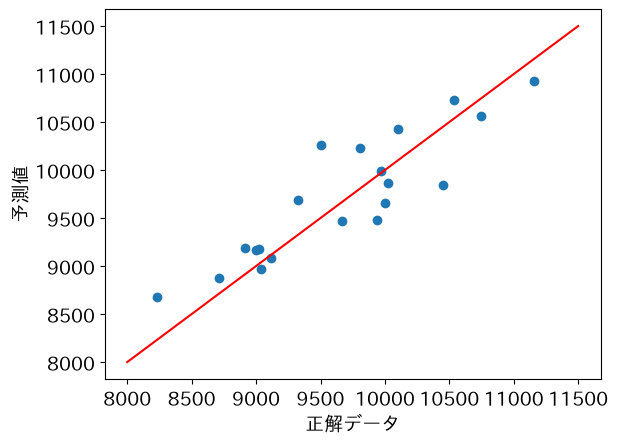

In [5]:
# モデルの当てはまりの良さの可視化
df = pd.read_csv('cinema.csv')
df = df.fillna(df.mean())
df = df.drop(30, axis=0)
x_cols = ['SNS1', 'SNS2', 'actor', 'original']
t_col = ['sales']
x = df[x_cols]
t = df[t_col]
from sklearn.model_selection import train_test_split
x_train, x_test, t_train, t_test = train_test_split(x, t, test_size=0.2, random_state=random_seed)
from sklearn.linear_model import LinearRegression
linear_regression_model = LinearRegression()
linear_regression_model.fit(X=x_train, y=t_train)
t_pred = linear_regression_model.predict(X=x_test)
plt.scatter(t_test, t_pred)
plt.xlabel('正解データ')
plt.ylabel('予測値')
plt.plot([8000, 11500], [8000, 11500], color='red')
plt.show()

# 参考文献・資料
* 松尾豊(監修): 東京大学のデータサイエンティスト育成講座, マイナビ出版, 2019